In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
from tensorflow.keras import layers, Model, mixed_precision
import os
import time
import numpy as np
import matplotlib.image as mpimg

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
mixed_precision.set_global_policy('mixed_float16')

In [3]:
IMG_SIZE = 64
BATCH_SIZE = 256

img_dir = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
image_paths = glob.glob(img_dir + "/*.jpg")
print("Total images found:", len(image_paths))

image_paths = image_paths[:50000]  
print("Using:", len(image_paths))

Total images found: 202599
Using: 50000


In [4]:
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_crop_or_pad(img, 160, 160)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = (img - 127.5) / 127.5
    return img

ds = tf.data.Dataset.from_tensor_slices(image_paths)
ds = (ds
      .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
      .cache()
      .shuffle(10000)
      .batch(BATCH_SIZE, drop_remainder=True)
      .prefetch(tf.data.AUTOTUNE))

I0000 00:00:1785105986.180318      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785105986.183150      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


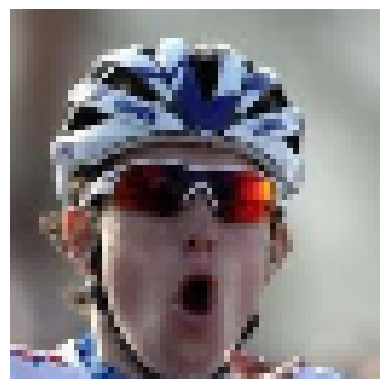

In [5]:
for batch in ds.take(1):
    plt.imshow((batch[0] + 1) / 2)
    plt.axis('off')
    plt.show()

In [7]:
LATENT_DIM = 100


def build_generator():
    inputs = layers.Input(shape=(LATENT_DIM,))

    x = layers.Dense(4 * 4 * 256, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((4, 4, 256))(x)

    x = layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding='same',
                                use_bias=False, activation='tanh', dtype='float32')(x)

    return Model(inputs, x, name='generator')

generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     1,048,576 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,134,784 (8.14 MB)

 Trainable params: 2,125,696 (8.11 MB)

 Non-trainable params: 9,088 (35.50 KB)

In [8]:
noise = tf.random.normal([1, LATENT_DIM])
fake_img = generator(noise, training=False)
print(fake_img.shape)

(1, 64, 64, 3)


In [9]:
def build_discriminator():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, kernel_size=4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(512, kernel_size=4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, dtype='float32')(x)

    return Model(inputs, x, name='discriminator')

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [10]:
decision = discriminator(fake_img, training=False)
print(decision.shape)

(1, 1)


In [11]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [12]:
gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

In [13]:
gen_optimizer.build(generator.trainable_variables)
disc_optimizer.build(discriminator.trainable_variables)

In [15]:
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [16]:
EPOCHS = 150
NUM_EXAMPLES_TO_GENERATE = 16
sample_dir = "/kaggle/working/samples"
os.makedirs(sample_dir, exist_ok=True)

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])
gen_losses = []
disc_losses = []

In [17]:
gen_losses = []
disc_losses = []

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis('off')
    plt.savefig(f"{sample_dir}/epoch_{epoch:03d}.png")
    plt.close(fig)

In [18]:
CHECKPOINT_EVERY = 10


for epoch in range(1, EPOCHS + 1):
    start = time.time()
    epoch_gen_loss, epoch_disc_loss = [], []
    batch_count = 0
    for batch in ds:
        g_loss, d_loss = train_step(batch)
        epoch_gen_loss.append(g_loss.numpy())
        epoch_disc_loss.append(d_loss.numpy())
        batch_count += 1
        if batch_count % 50 == 0:
            print(f"  batch {batch_count} | g_loss: {g_loss:.4f} | d_loss: {d_loss:.4f}")
    avg_g = np.mean(epoch_gen_loss)
    avg_d = np.mean(epoch_disc_loss)
    gen_losses.append(avg_g)
    disc_losses.append(avg_d)
    generate_and_save_images(generator, epoch, seed)

    if epoch % CHECKPOINT_EVERY == 0:
        generator.save(f"/kaggle/working/generator_epoch{epoch}.keras")
        discriminator.save(f"/kaggle/working/discriminator_epoch{epoch}.keras")
        print(f"  ✓ Checkpoint saved at epoch {epoch}")

    print(f"Epoch {epoch}/{EPOCHS} | gen_loss: {avg_g:.4f} | disc_loss: {avg_d:.4f} | time: {time.time()-start:.1f}s")

  batch 50 | g_loss: 5.8166 | d_loss: 0.0621
  batch 100 | g_loss: 2.7733 | d_loss: 0.5011
  batch 150 | g_loss: 2.5997 | d_loss: 0.4262
Epoch 1/150 | gen_loss: 5.5284 | disc_loss: 0.3404 | time: 78.2s
  batch 50 | g_loss: 2.2642 | d_loss: 0.5461
  batch 100 | g_loss: 3.4073 | d_loss: 0.4426
  batch 150 | g_loss: 3.1415 | d_loss: 0.3259
Epoch 2/150 | gen_loss: 2.9965 | disc_loss: 0.5296 | time: 21.5s
  batch 50 | g_loss: 2.8092 | d_loss: 0.3699
  batch 100 | g_loss: 1.8043 | d_loss: 0.6506
  batch 150 | g_loss: 3.6349 | d_loss: 0.4040
Epoch 3/150 | gen_loss: 3.0795 | disc_loss: 0.5233 | time: 21.8s
  batch 50 | g_loss: 4.0271 | d_loss: 0.3883
  batch 100 | g_loss: 4.0407 | d_loss: 0.3124
  batch 150 | g_loss: 2.7017 | d_loss: 0.5125
Epoch 4/150 | gen_loss: 2.8963 | disc_loss: 0.5359 | time: 22.0s
  batch 50 | g_loss: 4.1997 | d_loss: 0.3253
  batch 100 | g_loss: 2.4621 | d_loss: 0.4106
  batch 150 | g_loss: 3.2859 | d_loss: 0.3187
Epoch 5/150 | gen_loss: 3.1034 | disc_loss: 0.4458 | ti

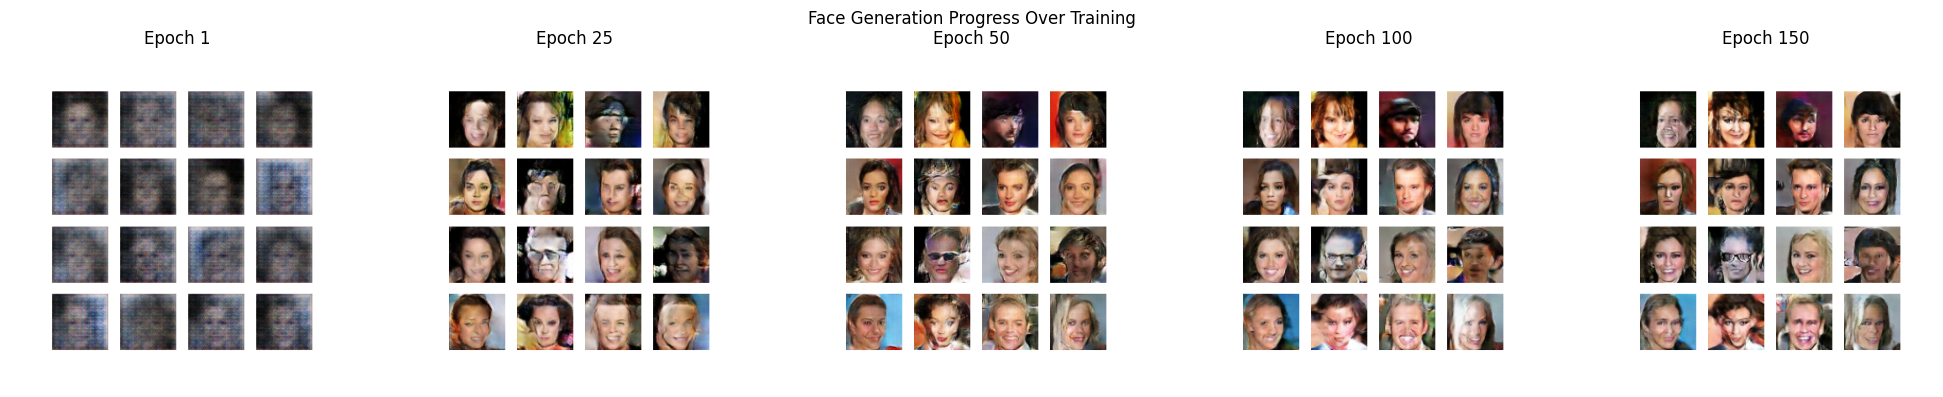

In [19]:
epochs_to_show = [1, 25, 50, 100, 150]
fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(20, 4))
for ax, ep in zip(axes, epochs_to_show):
    img = mpimg.imread(f"{sample_dir}/epoch_{ep:03d}.png")
    ax.imshow(img)
    ax.set_title(f"Epoch {ep}")
    ax.axis('off')
plt.suptitle("Face Generation Progress Over Training")
plt.tight_layout()
plt.show()

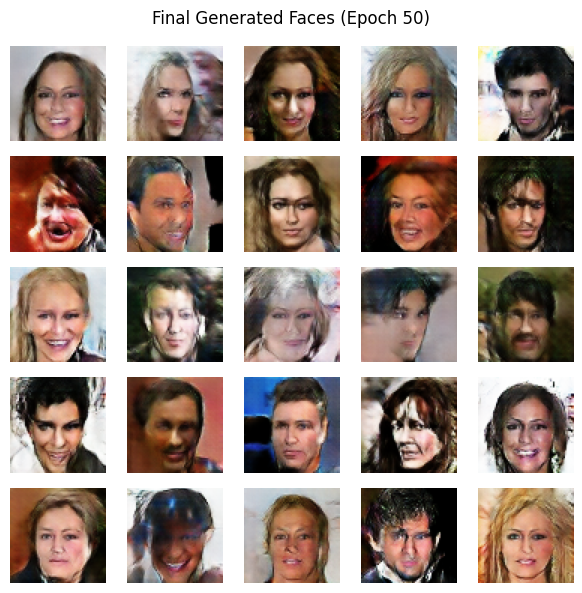

In [20]:
num_final = 25
new_noise = tf.random.normal([num_final, LATENT_DIM])
final_faces = generator(new_noise, training=False)
final_faces = (final_faces + 1) / 2.0

fig = plt.figure(figsize=(6, 6))
for i in range(num_final):
    plt.subplot(5, 5, i + 1)
    plt.imshow(final_faces[i])
    plt.axis('off')
plt.suptitle("Final Generated Faces (Epoch 50)")
plt.tight_layout()
plt.show()

In [21]:
generator.save("/kaggle/working/face_generator.keras")
discriminator.save("/kaggle/working/face_discriminator.keras")

In [22]:
generator = tf.keras.models.load_model("face_generator.keras")

noise = tf.random.normal([16, 100])  
faces = generator(noise, training=False)
faces = (faces + 1) / 2.0 